In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Visualización de los datos importantes para la predicción

## Goles a favor contra número de victorias cada año

### Cargar los datos de una temporada

In [2]:
archivos = ['SP1-1011.csv','SP1-1112.csv','SP1-1213.csv','SP1-1314.csv','SP1-1415.csv','SP1-1516.csv','SP1-1617.csv', 'SP1-1718.csv',
            'SP1-1819.csv', 'SP1-1920.csv', 'SP1-2021.csv', 'SP1-2122.csv', 
            'SP1-2223.csv', 'SP1-2324.csv']

archivos = ['SP1-1819.csv', 'SP1-1920.csv', 'SP1-2021.csv', 'SP1-2122.csv', 'SP1-2223.csv']
archivos_empates_visitantes = ['SP1-1314.csv','SP1-1415.csv','SP1-1516.csv','SP1-1617.csv', 'SP1-1718.csv']

dataframes = []
dataframes_empates_visitantes = []

for archivo in archivos_empates_visitantes:
    # Leer el archivo y almacenar el DataFrame en la lista
    df = pd.read_csv("Datos_Formateados/"+archivo)
    dataframes_empates_visitantes.append(df)
    
for archivo in archivos:
    # Leer el archivo y almacenar el DataFrame en la lista
    df = pd.read_csv("Datos_Formateados/"+archivo)
    dataframes.append(df)

# Concatenar todos los DataFrames en uno solo
dataframe_liga = pd.concat(dataframes, ignore_index=True)
dataframe_liga_empates_visitante = pd.concat(dataframes_empates_visitantes, ignore_index=True)
dataframe_liga.shape

(1900, 17)

### Conseguir los equipos de esa temporada

In [3]:
def get_equipos(dataframe: pd.DataFrame) -> list:
    list = []
    for idx in dataframe.index:
        if dataframe['HomeTeam'][idx] not in list:
            list.append(dataframe['HomeTeam'][idx])
        if dataframe['AwayTeam'][idx] not in list:
            list.append(dataframe['AwayTeam'][idx])
    return list

equipos = get_equipos(dataframe=dataframe_liga)
len(equipos)

26

### Conseguir el número de goles a favor de la temporada de cada equipo

In [4]:
def get_goles_a_favor(dataframe: pd.DataFrame, equipo: str) -> int:
    goles_local = dataframe.loc[dataframe['HomeTeam'] == equipo, 'FTHG'].sum()
    goles_visitante = dataframe.loc[dataframe['AwayTeam'] == equipo, 'FTAG'].sum()
    return goles_local + goles_visitante

for equipo in equipos:
    goles = get_goles_a_favor(dataframe=dataframe_liga, equipo=equipo)
    #print("El "+equipo+" ha marcado: "+str(goles)+" goles")

### Conseguir el número de victorias de cada equipo

In [5]:
def get_victorias(dataframe: pd.DataFrame, equipo: str) -> int:
    victorias_local = len(dataframe[(dataframe['HomeTeam'] == equipo) & (dataframe['FTR'] == 'H')])
    victorias_visitante = len(dataframe[(dataframe['AwayTeam'] == equipo) & (dataframe['FTR'] == 'A')])
    empates_local = len(dataframe[(dataframe['HomeTeam'] == equipo) & (dataframe['FTR'] == 'D')])
    empates_visitante = len(dataframe[(dataframe['AwayTeam'] == equipo) & (dataframe['FTR'] == 'D')])
    return victorias_local + victorias_visitante

for equipo in equipos:
    victorias = get_victorias(dataframe=dataframe_liga, equipo=equipo)
    #print("El "+equipo+" ha ganado: "+str(victorias)+" partidos")

### Graficar los datos

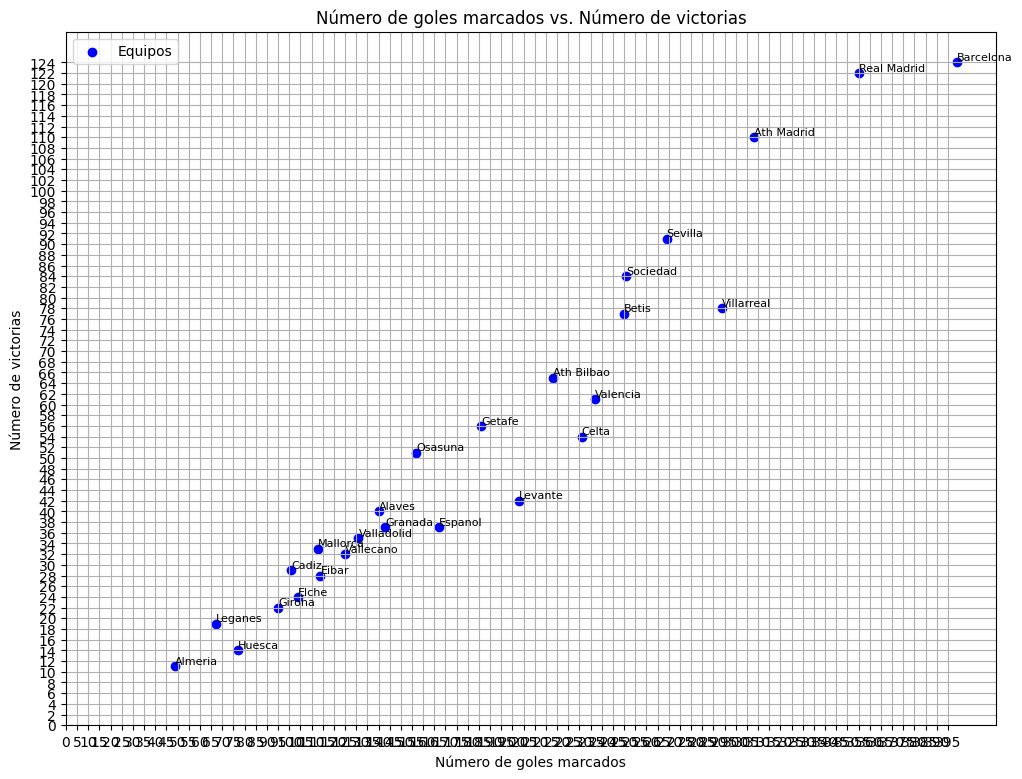

In [6]:
equipos = get_equipos(dataframe=dataframe_liga)
goles_marcados_todos_equipos = []
victorias_todos_equipos = []
for equipo in equipos:
    goles_marcados_todos_equipos.append(get_goles_a_favor(dataframe=dataframe_liga, equipo=equipo))
    victorias_todos_equipos.append(get_victorias(dataframe=dataframe_liga, equipo=equipo))
maximos_goles = max(goles_marcados_todos_equipos)
maximas_victorias = max(victorias_todos_equipos)

plt.figure(figsize=(12, 9))
plt.scatter(goles_marcados_todos_equipos, victorias_todos_equipos, color='blue', label='Equipos')  # Puntos en la gráfica para cada equipo
for i, equipo in enumerate(equipos):
    plt.text(goles_marcados_todos_equipos[i], victorias_todos_equipos[i], equipo, fontsize=8, ha='left', va='bottom')
plt.xlabel('Número de goles marcados')
plt.ylabel('Número de victorias')
plt.title('Número de goles marcados vs. Número de victorias')
plt.xticks(range(0, maximos_goles+1, 5))  # Definir los límites y el paso del eje x
plt.yticks(range(0, maximas_victorias+1, 2))  # Definir los límites y el paso del eje y
plt.grid(True)
plt.legend()
plt.show()

## Goles en contra vs victorias cada año

### Conseguir goles en contra de cada equipo cada año

In [7]:
def get_goles_en_contra(dataframe: pd.DataFrame, equipo: str) -> int:
    goles_encajados_local = dataframe.loc[dataframe['HomeTeam'] == equipo, 'FTAG'].sum()
    goles_encajados_visitante = dataframe.loc[dataframe['AwayTeam'] == equipo, 'FTHG'].sum()
    return goles_encajados_local + goles_encajados_visitante

for equipo in equipos:
    goles = get_goles_en_contra(dataframe=dataframe_liga, equipo=equipo)
    #print("El "+equipo+" ha encajado: "+str(goles)+" goles")

### Graficar los datos

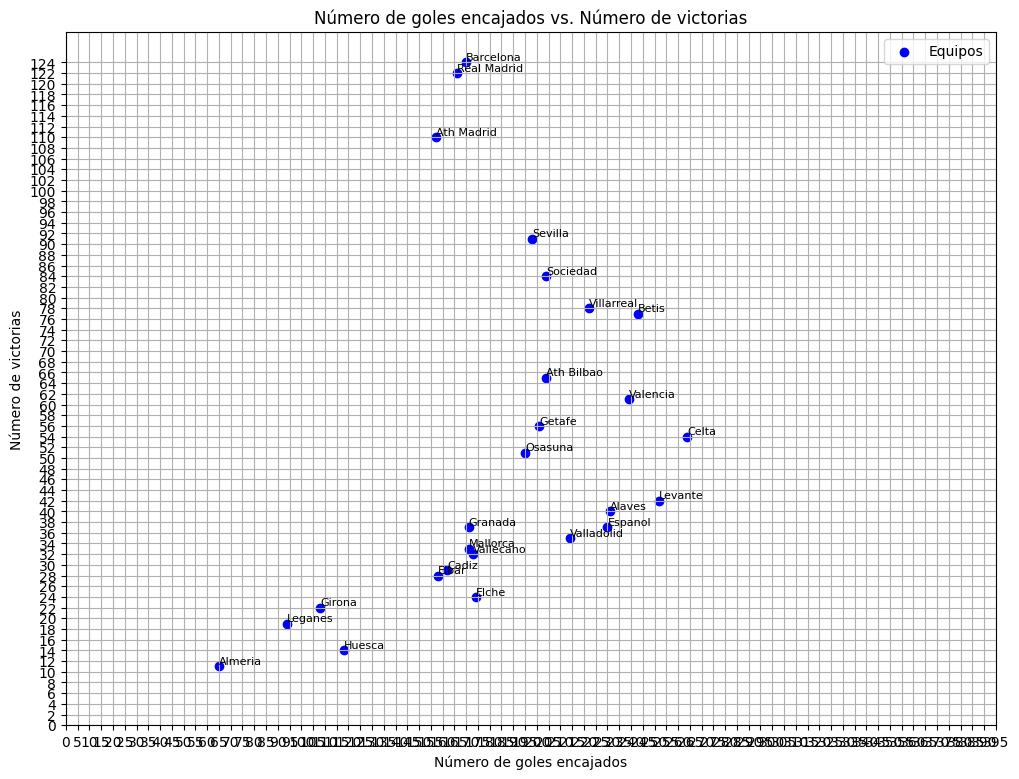

In [8]:
equipos = get_equipos(dataframe=dataframe_liga)
goles_encajados_todos_equipos = []
victorias_todos_equipos = []
for equipo in equipos:
    goles_encajados_todos_equipos.append(get_goles_en_contra(dataframe=dataframe_liga, equipo=equipo))
    victorias_todos_equipos.append(get_victorias(dataframe=dataframe_liga, equipo=equipo))
maximos_goles = max(goles_marcados_todos_equipos)
maximas_victorias = max(victorias_todos_equipos)

plt.figure(figsize=(12, 9))
plt.scatter(goles_encajados_todos_equipos, victorias_todos_equipos, color='blue', label='Equipos')  # Puntos en la gráfica para cada equipo
for i, equipo in enumerate(equipos):
    plt.text(goles_encajados_todos_equipos[i], victorias_todos_equipos[i], equipo, fontsize=8, ha='left', va='bottom')
plt.xlabel('Número de goles encajados')
plt.ylabel('Número de victorias')
plt.title('Número de goles encajados vs. Número de victorias')
plt.xticks(range(0, maximos_goles+1, 5))  # Definir los límites y el paso del eje x
plt.yticks(range(0, maximas_victorias+1, 2))  # Definir los límites y el paso del eje y
plt.grid(True)
plt.legend()
plt.show()

## Fusionar ambos datos

### Primera aproximación: Gol Average

In [9]:
def get_gol_average(dataframe: pd.DataFrame, equipo: str) -> int:
    goles_a_favor = get_goles_a_favor(dataframe=dataframe, equipo=equipo)
    goles_en_contra = get_goles_en_contra(dataframe=dataframe, equipo=equipo)
    return goles_a_favor - goles_en_contra

for equipo in equipos:
    gol_average = get_gol_average(dataframe=dataframe_liga, equipo=equipo)
    #print("El "+equipo+" tiene un gol average de: "+str(gol_average))

### Graficar los datos

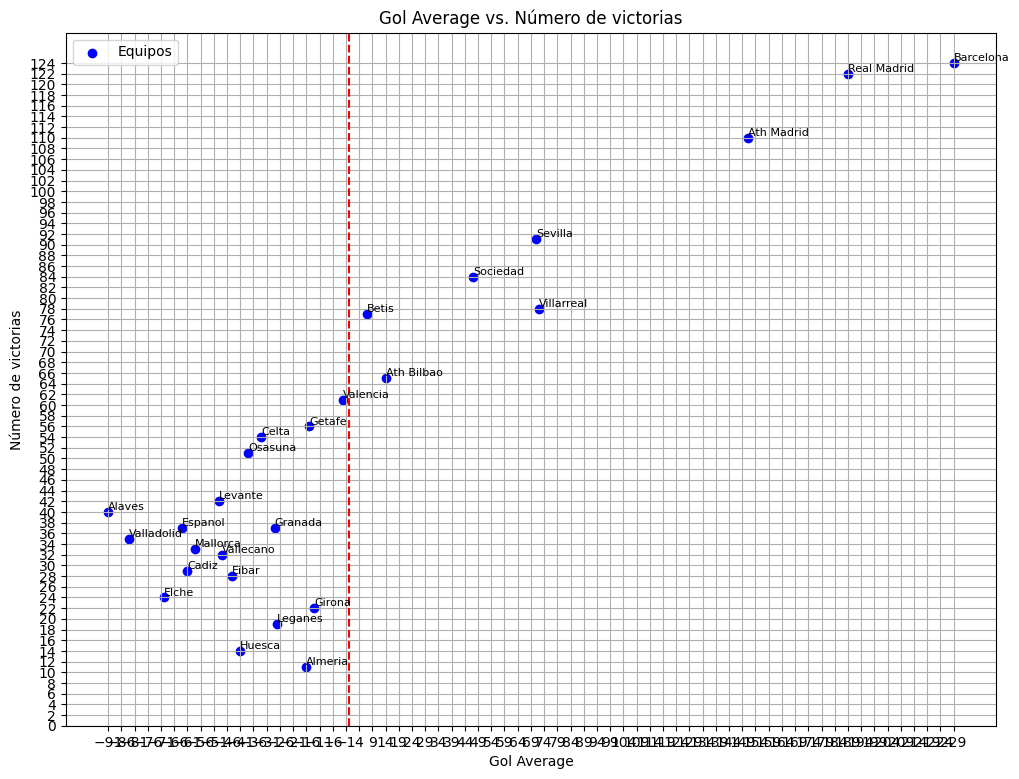

In [10]:
equipos = get_equipos(dataframe=dataframe_liga)
gol_average_todos_equipos = []
victorias_todos_equipos = []
for equipo in equipos:
    gol_average_todos_equipos.append(get_gol_average(dataframe=dataframe_liga, equipo=equipo))
    victorias_todos_equipos.append(get_victorias(dataframe=dataframe_liga, equipo=equipo))
minimo_goles = min(gol_average_todos_equipos)
maximos_goles = max(gol_average_todos_equipos)
maximas_victorias = max(victorias_todos_equipos)

plt.figure(figsize=(12, 9))
plt.scatter(gol_average_todos_equipos, victorias_todos_equipos, color='blue', label='Equipos')  # Puntos en la gráfica para cada equipo
for i, equipo in enumerate(equipos):
    plt.text(gol_average_todos_equipos[i], victorias_todos_equipos[i], equipo, fontsize=8, ha='left', va='bottom')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Gol Average')
plt.ylabel('Número de victorias')
plt.title('Gol Average vs. Número de victorias')
plt.xticks(range(minimo_goles, maximos_goles+1, 5))  # Definir los límites y el paso del eje x
plt.yticks(range(0, maximas_victorias+1, 2))  # Definir los límites y el paso del eje y
plt.grid(True)
plt.legend()
plt.show()

### Segunda aproximación: media de goles marcados por partido

In [11]:
def get_media_goles_marcados(dataframe: pd.DataFrame, equipo: str) -> float:
    goles_marcados = get_goles_a_favor(dataframe=dataframe, equipo=equipo)
    equipos = get_equipos(dataframe=dataframe)
    partidos_jugados = 2 * len(dataframe) / len(equipos)
    return goles_marcados / partidos_jugados

for equipo in equipos:
    media_goles_marcados = get_media_goles_marcados(dataframe=dataframe_liga, equipo=equipo)
    #print("El "+equipo+" tiene una media de goles marcados por partido de: "+str(media_goles_marcados))

### Graficar datos

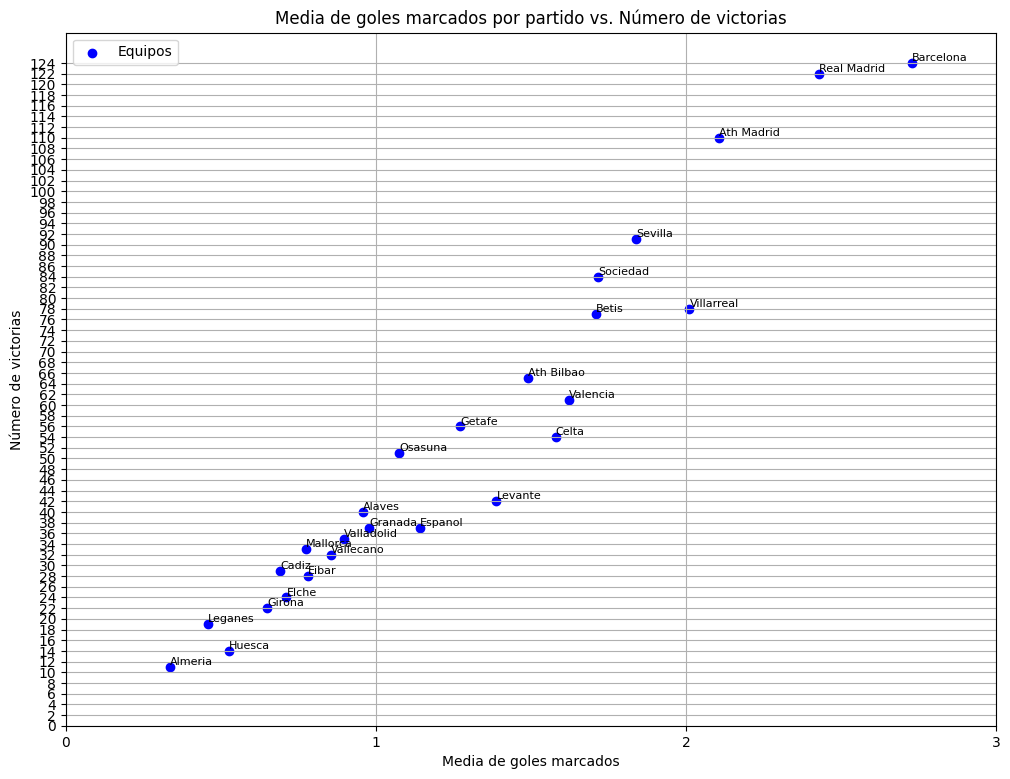

In [12]:
equipos = get_equipos(dataframe=dataframe_liga)
media_goles_todos_equipos = []
victorias_todos_equipos = []
for equipo in equipos:
    media_goles_todos_equipos.append(get_media_goles_marcados(dataframe=dataframe_liga, equipo=equipo))
    victorias_todos_equipos.append(get_victorias(dataframe=dataframe_liga, equipo=equipo))
maximos_goles = max(media_goles_todos_equipos)
maximas_victorias = max(victorias_todos_equipos)

plt.figure(figsize=(12, 9))
plt.scatter(media_goles_todos_equipos, victorias_todos_equipos, color='blue', label='Equipos')  # Puntos en la gráfica para cada equipo
for i, equipo in enumerate(equipos):
    plt.text(media_goles_todos_equipos[i], victorias_todos_equipos[i], equipo, fontsize=8, ha='left', va='bottom')
plt.xlabel('Media de goles marcados')
plt.ylabel('Número de victorias')
plt.title('Media de goles marcados por partido vs. Número de victorias')
plt.xticks(range(0, round(maximos_goles)+1, 1))  # Definir los límites y el paso del eje x
plt.yticks(range(0, maximas_victorias+1, 2))  # Definir los límites y el paso del eje y
plt.grid(True)
plt.legend()
plt.show()

### Tercera aproximación: Media de goles encajados por partido

In [13]:
def get_media_goles_encajados(dataframe: pd.DataFrame, equipo: str) -> float:
    goles_encajados = get_goles_en_contra(dataframe=dataframe, equipo=equipo)
    equipos = get_equipos(dataframe=dataframe)
    partidos_jugados = 2 * len(dataframe) / len(equipos)
    return goles_encajados / partidos_jugados

for equipo in equipos:
    media_goles_encajados = get_media_goles_encajados(dataframe=dataframe_liga, equipo=equipo)
    #print("El "+equipo+" tiene una media de goles encajados por partido de: "+str(media_goles_encajados))

### Graficar los datos

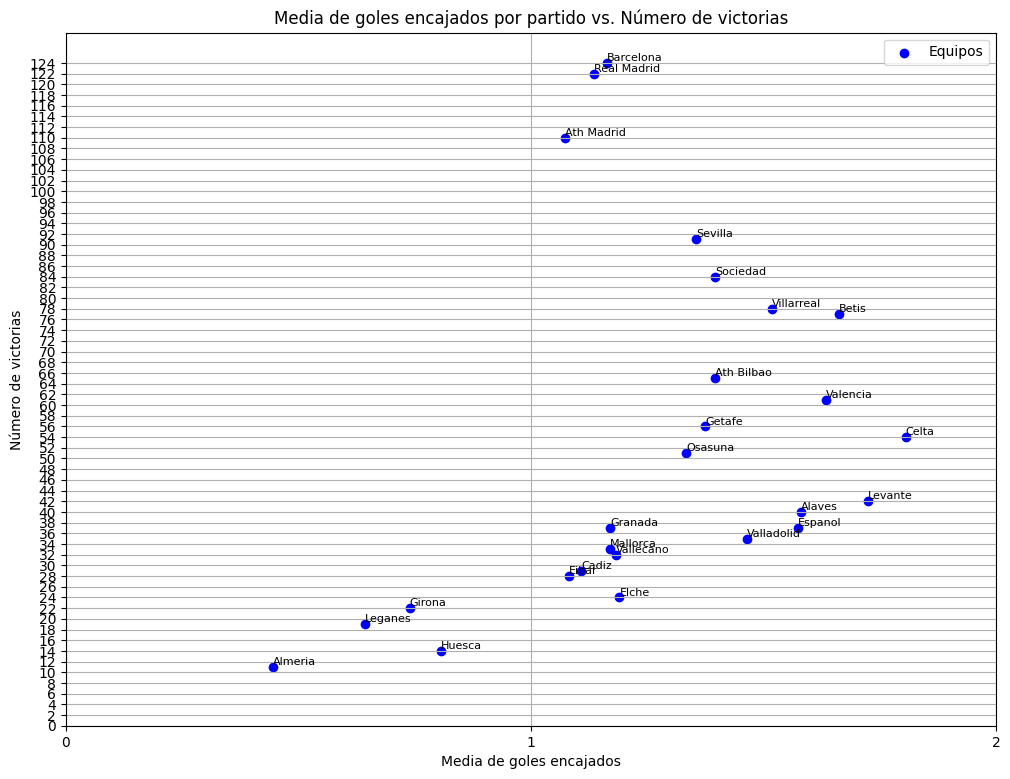

In [14]:
equipos = get_equipos(dataframe=dataframe_liga)
media_goles_encajados_todos_equipos = []
victorias_todos_equipos = []
for equipo in equipos:
    media_goles_encajados_todos_equipos.append(get_media_goles_encajados(dataframe=dataframe_liga, equipo=equipo))
    victorias_todos_equipos.append(get_victorias(dataframe=dataframe_liga, equipo=equipo))
maximos_goles = max(media_goles_encajados_todos_equipos)
maximas_victorias = max(victorias_todos_equipos)

plt.figure(figsize=(12, 9))
plt.scatter(media_goles_encajados_todos_equipos, victorias_todos_equipos, color='blue', label='Equipos')  # Puntos en la gráfica para cada equipo
for i, equipo in enumerate(equipos):
    plt.text(media_goles_encajados_todos_equipos[i], victorias_todos_equipos[i], equipo, fontsize=8, ha='left', va='bottom')
plt.xlabel('Media de goles encajados')
plt.ylabel('Número de victorias')
plt.title('Media de goles encajados por partido vs. Número de victorias')
plt.xticks(range(0, round(maximos_goles)+1, 1))  # Definir los límites y el paso del eje x
plt.yticks(range(0, maximas_victorias+1, 2))  # Definir los límites y el paso del eje y
plt.grid(True)
plt.legend()
plt.show()

### Cuarta aproximación: Media goles marcados - Media goles encajados

In [15]:
def get_media_goles_marcados_menos_encajados(dataframe: pd.DataFrame, equipo: str) -> float:
    goles_encajados = get_media_goles_encajados(dataframe=dataframe, equipo=equipo)
    goles_marcados = get_media_goles_marcados(dataframe=dataframe, equipo=equipo)
    return goles_marcados - goles_encajados

for equipo in equipos:
    media_goles_marcados_menos_encajados = get_media_goles_marcados_menos_encajados(dataframe=dataframe_liga, equipo=equipo)
    #print("El "+equipo+" tiene una media de goles marcados - encajados por partido de: "+str(media_goles_marcados_menos_encajados))

### Graficar datos

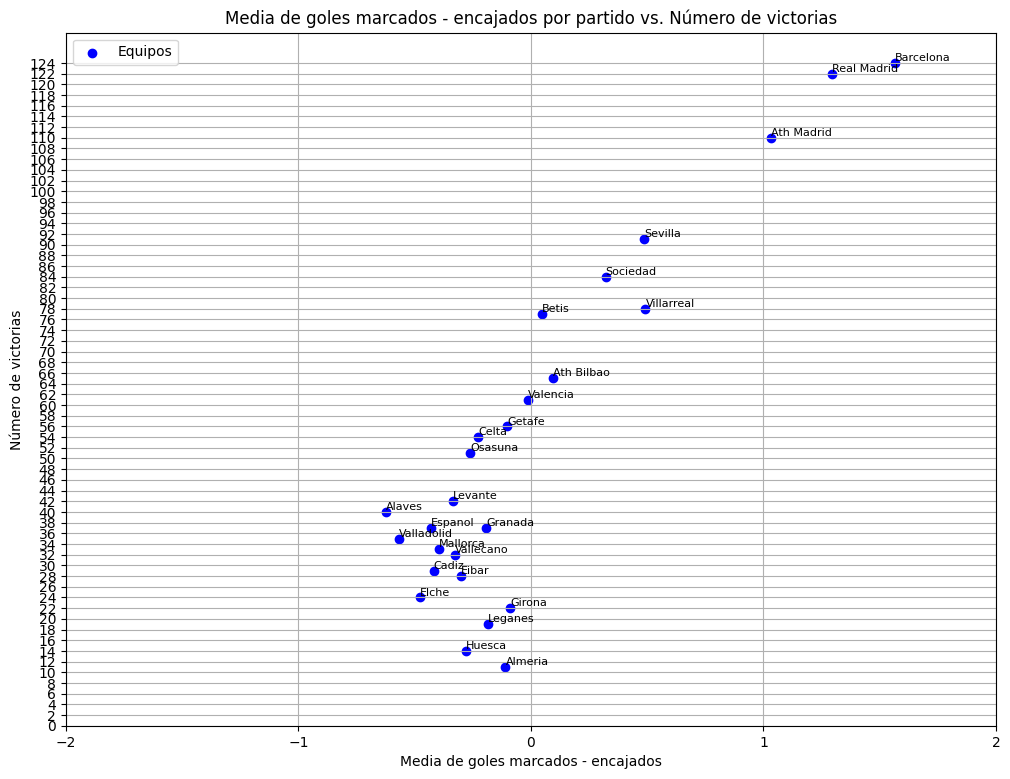

In [16]:
equipos = get_equipos(dataframe=dataframe_liga)
media_goles_marcados_menos_encajados_todos_equipos = []
victorias_todos_equipos = []
for equipo in equipos:
    media_goles_marcados_menos_encajados_todos_equipos.append(get_media_goles_marcados_menos_encajados(dataframe=dataframe_liga, equipo=equipo))
    victorias_todos_equipos.append(get_victorias(dataframe=dataframe_liga, equipo=equipo))
minimo_goles = min(media_goles_marcados_menos_encajados_todos_equipos)
maximos_goles = max(media_goles_marcados_menos_encajados_todos_equipos)
maximas_victorias = max(victorias_todos_equipos)

plt.figure(figsize=(12, 9))
plt.scatter(media_goles_marcados_menos_encajados_todos_equipos, victorias_todos_equipos, color='blue', label='Equipos')  # Puntos en la gráfica para cada equipo
for i, equipo in enumerate(equipos):
    plt.text(media_goles_marcados_menos_encajados_todos_equipos[i], victorias_todos_equipos[i], equipo, fontsize=8, ha='left', va='bottom')
plt.xlabel('Media de goles marcados - encajados')
plt.ylabel('Número de victorias')
plt.title('Media de goles marcados - encajados por partido vs. Número de victorias')
plt.xticks(range(round(minimo_goles)-1, round(maximos_goles)+1, 1))  # Definir los límites y el paso del eje x
plt.yticks(range(0, maximas_victorias+1, 2))  # Definir los límites y el paso del eje y
plt.grid(True)
plt.legend()
plt.show()

## Relevancia de Local o Visitante

### ¿Es importante el campo donde se juega?

In [17]:
def get_resultados_totales(dataframe: pd.DataFrame) -> list:
    victorias_local = len(dataframe.loc[dataframe['FTR'] == 'H'])
    empates = len(dataframe.loc[dataframe['FTR'] == 'D'])
    victorias_visitante = len(dataframe.loc[dataframe['FTR'] == 'A'])
    return (victorias_local,empates,victorias_visitante)

resultados = get_resultados_totales(dataframe=dataframe_liga)
#print("Victorias local: "+str(resultados[0]))
#print("Empates: "+str(resultados[1]))
#print("Victorias visitante: "+str(resultados[2]))

### Graficar datos

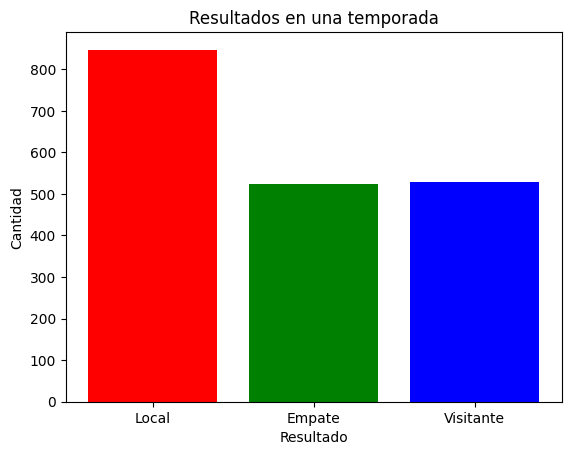

In [18]:
resultados = get_resultados_totales(dataframe=dataframe_liga)
variables = ['Local','Empate','Visitante']

plt.bar(variables, resultados, color=['red', 'green', 'blue'])

plt.xlabel('Resultado')
plt.ylabel('Cantidad')
plt.title('Resultados en una temporada')

plt.show()

## Importancia de las tarjetas rojas

In [83]:
def get_media_rojas(dataframe: pd.DataFrame, equipo: str) -> float:
    rojas_local = dataframe.loc[dataframe['HomeTeam'] == equipo, 'HR'].sum()
    rojas_visitante = dataframe.loc[dataframe['AwayTeam'] == equipo, 'AR'].sum()
    partidos_jugados = 2 * len(dataframe) / len(equipos)
    return (rojas_local + rojas_visitante) / partidos_jugados

for equipo in equipos:
    media_rojas = get_media_rojas(dataframe=dataframe_liga, equipo=equipo)
    #print("El "+equipo+" tiene una media de rojas de "+str(media_rojas))

### Graficar datos

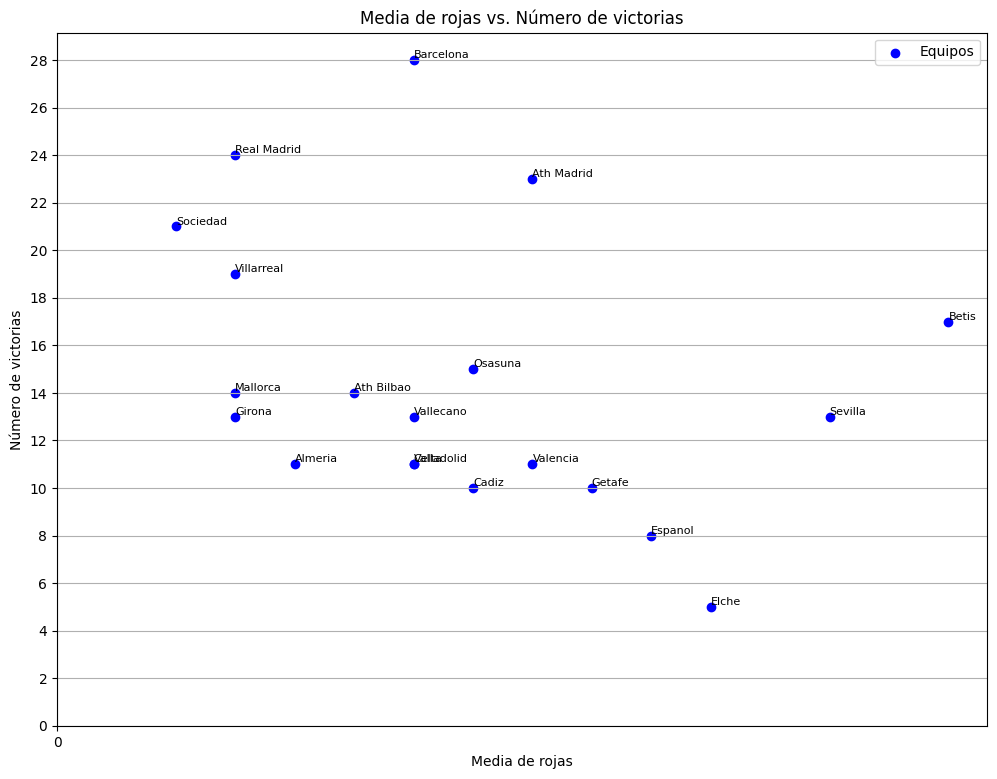

In [84]:
equipos = get_equipos(dataframe=dataframe_liga)
media_rojas_todos_equipos = []
victorias_todos_equipos = []
for equipo in equipos:
    media_rojas_todos_equipos.append(get_media_rojas(dataframe=dataframe_liga, equipo=equipo))
    victorias_todos_equipos.append(get_victorias(dataframe=dataframe_liga, equipo=equipo))
maximos_goles = max(media_rojas_todos_equipos)
maximas_victorias = max(victorias_todos_equipos)

plt.figure(figsize=(12, 9))
plt.scatter(media_rojas_todos_equipos, victorias_todos_equipos, color='blue', label='Equipos')  # Puntos en la gráfica para cada equipo
for i, equipo in enumerate(equipos):
    plt.text(media_rojas_todos_equipos[i], victorias_todos_equipos[i], equipo, fontsize=8, ha='left', va='bottom')
plt.xlabel('Media de rojas')
plt.ylabel('Número de victorias')
plt.title('Media de rojas vs. Número de victorias')
plt.xticks(range(0, round(maximos_goles)+1, 1))  # Definir los límites y el paso del eje x
plt.yticks(range(0, maximas_victorias+1, 2))  # Definir los límites y el paso del eje y
plt.grid(True)
plt.legend()
plt.show()

## Racha de victorias

In [85]:
def get_resultados_equipo(dataframe: pd.DataFrame, equipo=equipo) -> list:
    lista_resultados = []
    for idx, fila in dataframe.iterrows():
        if fila['HomeTeam'] == equipo:
            if fila['FTR'] == 'H':
                lista_resultados.append('W')
            elif fila['FTR'] == 'A':
                lista_resultados.append('D')
            else:
                lista_resultados.append('L')
        if fila['AwayTeam'] == equipo:
            if fila['FTR'] == 'A':
                lista_resultados.append('W')
            elif fila['FTR'] == 'H':
                lista_resultados.append('D')
            else:
                lista_resultados.append('L')
    return lista_resultados

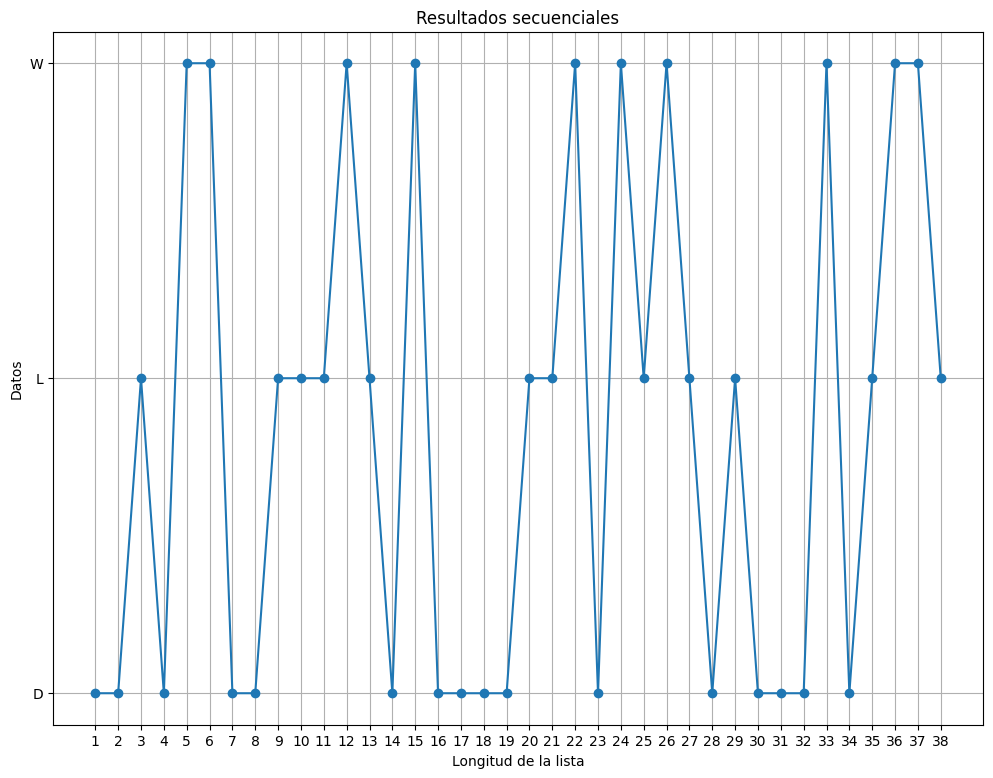

In [86]:
datos = get_resultados_equipo(dataframe=dataframe_liga, equipo="Getafe")
longitud = len(datos)
plt.figure(figsize=(12, 9))
plt.plot(range(1, longitud + 1), datos, marker='o')

plt.xticks(range(1, longitud + 1))

plt.xlabel('Longitud de la lista')
plt.ylabel('Datos')

plt.title('Resultados secuenciales')

# Mostrar la gráfica
plt.grid(True)
plt.show()

## Diferencia de gol average medio entre un partido y el anterior

### Goles marcados por partido

In [87]:
def get_goles_marcados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_por_partido = []
    partidos_del_equipo = dataframe.loc[(dataframe['HomeTeam'] == equipo) | (dataframe['AwayTeam'] == equipo)]
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HomeTeam'] == equipo:
            lista_goles_por_partido.append(partido['FTHG'])
        if partido['AwayTeam'] == equipo:
            lista_goles_por_partido.append(partido['FTAG'])
    return lista_goles_por_partido

lista = get_goles_marcados_por_partido(dataframe=dataframe_liga, equipo="Celta")
print(lista)

[2, 1, 1, 3, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 4, 0, 1, 3, 0, 3, 3, 2, 2, 0, 0, 1, 1, 0, 1, 1, 1, 0, 2]


### Goles encajados por partido

In [88]:
def get_goles_encajados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_por_partido = []
    partidos_del_equipo = dataframe.loc[(dataframe['HomeTeam'] == equipo) | (dataframe['AwayTeam'] == equipo)]
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HomeTeam'] == equipo:
            lista_goles_por_partido.append(partido['FTAG'])
        if partido['AwayTeam'] == equipo:
            lista_goles_por_partido.append(partido['FTHG'])
    return lista_goles_por_partido

lista = get_goles_encajados_por_partido(dataframe=dataframe_liga, equipo="Celta")
print(lista)

[2, 4, 0, 0, 4, 3, 0, 1, 2, 4, 1, 3, 2, 0, 1, 0, 1, 1, 0, 3, 1, 1, 0, 0, 0, 1, 2, 2, 1, 2, 0, 3, 1, 2, 2, 1, 1, 1]


### Media goles marcados por partido

In [89]:
def get_media_goles_marcados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_por_partido = get_goles_marcados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_goles_por_partido = []
    goles_acumulados = 0
    for idx, valor in enumerate(lista_goles_por_partido):
        lista_media_goles_por_partido.append((valor + goles_acumulados) / (idx+1))
        goles_acumulados += valor
    return lista_media_goles_por_partido
lista = get_media_goles_marcados_por_partido(dataframe=dataframe_liga, equipo="Celta")
print(lista)

[2.0, 1.5, 1.3333333333333333, 1.75, 1.6, 1.3333333333333333, 1.2857142857142858, 1.125, 1.1111111111111112, 1.1, 1.0909090909090908, 1.0833333333333333, 1.0769230769230769, 1.0, 1.0, 1.0, 1.0, 0.9444444444444444, 0.9473684210526315, 1.1, 1.0476190476190477, 1.0454545454545454, 1.1304347826086956, 1.0833333333333333, 1.16, 1.2307692307692308, 1.2592592592592593, 1.2857142857142858, 1.2413793103448276, 1.2, 1.1935483870967742, 1.1875, 1.1515151515151516, 1.1470588235294117, 1.1428571428571428, 1.1388888888888888, 1.1081081081081081, 1.131578947368421]


### Media goles encajados por partido

In [90]:
def get_media_goles_encajados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_por_partido = get_goles_encajados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_goles_por_partido = []
    goles_acumulados = 0
    for idx, valor in enumerate(lista_goles_por_partido):
        lista_media_goles_por_partido.append((valor + goles_acumulados) / (idx+1))
        goles_acumulados += valor
    return lista_media_goles_por_partido
lista = get_media_goles_encajados_por_partido(dataframe=dataframe_liga, equipo="Celta")
print(lista)

[2.0, 3.0, 2.0, 1.5, 2.0, 2.1666666666666665, 1.8571428571428572, 1.75, 1.7777777777777777, 2.0, 1.9090909090909092, 2.0, 2.0, 1.8571428571428572, 1.8, 1.6875, 1.6470588235294117, 1.6111111111111112, 1.5263157894736843, 1.6, 1.5714285714285714, 1.5454545454545454, 1.4782608695652173, 1.4166666666666667, 1.36, 1.3461538461538463, 1.3703703703703705, 1.3928571428571428, 1.3793103448275863, 1.4, 1.3548387096774193, 1.40625, 1.393939393939394, 1.411764705882353, 1.4285714285714286, 1.4166666666666667, 1.4054054054054055, 1.394736842105263]


### Gol average por partido

In [91]:
def get_gol_average_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_marcados_por_partido = get_goles_marcados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_goles_encajados_por_partido = get_goles_encajados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_gol_average_por_partido = []
    for idx, valor in enumerate(lista_goles_marcados_por_partido):
        lista_gol_average_por_partido.append(valor - lista_goles_encajados_por_partido[idx])
    return lista_gol_average_por_partido
lista = get_gol_average_por_partido(dataframe=dataframe_liga, equipo="Celta")
print(lista)

[0, -3, 1, 3, -3, -3, 1, -1, -1, -3, 0, -2, -1, 0, 0, 1, 0, -1, 1, 1, -1, 0, 3, 0, 3, 2, 0, 0, -1, -2, 1, -2, -1, -1, -1, 0, -1, 1]


### Gol average medio por partido

In [92]:
def get_media_gol_average_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_goles_marcados_por_partido = get_goles_marcados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_goles_encajados_por_partido = get_goles_encajados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_gol_average_por_partido = []
    valor_acumulado = 0
    for idx, valor in enumerate(lista_goles_marcados_por_partido):
        lista_media_gol_average_por_partido.append((valor - lista_goles_encajados_por_partido[idx] + valor_acumulado) / (idx+1))
        valor_acumulado += (valor - lista_goles_encajados_por_partido[idx])
    return lista_media_gol_average_por_partido
lista = get_media_gol_average_por_partido(dataframe=dataframe_liga, equipo="Celta")
print(lista)

[0.0, -1.5, -0.6666666666666666, 0.25, -0.4, -0.8333333333333334, -0.5714285714285714, -0.625, -0.6666666666666666, -0.9, -0.8181818181818182, -0.9166666666666666, -0.9230769230769231, -0.8571428571428571, -0.8, -0.6875, -0.6470588235294118, -0.6666666666666666, -0.5789473684210527, -0.5, -0.5238095238095238, -0.5, -0.34782608695652173, -0.3333333333333333, -0.2, -0.11538461538461539, -0.1111111111111111, -0.10714285714285714, -0.13793103448275862, -0.2, -0.16129032258064516, -0.21875, -0.24242424242424243, -0.2647058823529412, -0.2857142857142857, -0.2777777777777778, -0.2972972972972973, -0.2631578947368421]


## Graficar los datos

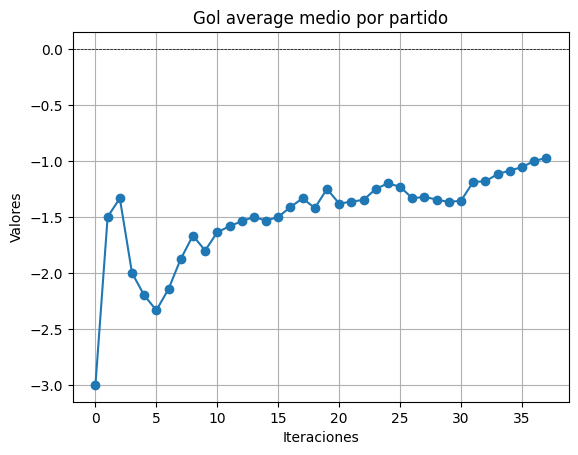

In [93]:
datos = get_media_gol_average_por_partido(dataframe=dataframe_liga, equipo="Elche")
iteraciones = range(len(datos))

plt.plot(iteraciones, datos, marker='o', linestyle='-')

plt.axhline(0, color='black', linewidth=0.5, linestyle='--')

plt.xlabel('Iteraciones')
plt.ylabel('Valores')

plt.title('Gol average medio por partido')

plt.grid(True)
plt.show()

### Diferencia de gol average medio respecto al partido anterior

In [94]:
def get_diferencia_media_gol_average_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_media_gol_average_por_partido = get_media_gol_average_por_partido(dataframe=dataframe, equipo=equipo)
    lista_diferencias = []
    primero = True
    valor_anterior = 0
    for valor in lista_media_gol_average_por_partido:
        lista_diferencias.append(valor - valor_anterior)
        valor_anterior = valor
    return lista_diferencias
lista = get_diferencia_media_gol_average_por_partido(dataframe=dataframe_liga, equipo="Barcelona")
print(lista)

[0.0, 1.5, 0.8333333333333335, 0.16666666666666652, 0.2999999999999998, 0.03333333333333366, -0.26190476190476186, -0.19642857142857162, -0.48611111111111116, 0.11111111111111116, 0.18181818181818166, -0.09848484848484818, -0.0064102564102563875, -0.0769230769230771, -0.1333333333333333, -0.054166666666666696, -0.047794117647058876, -0.0424836601307188, -0.03801169590643294, 0.06578947368421062, -0.03571428571428581, 0.012987012987013102, -0.11857707509881421, -0.025362318840579823, -0.023333333333333206, -0.021538461538461506, 0.09116809116809099, -0.05820105820105814, -0.054187192118226646, -0.01724137931034475, -0.08064516129032251, 0.08064516129032251, -0.015151515151515138, 0.015151515151515138, -0.0714285714285714, -0.09523809523809534, 0.04504504504504503, -0.06258890469416767]


### Graficar datos

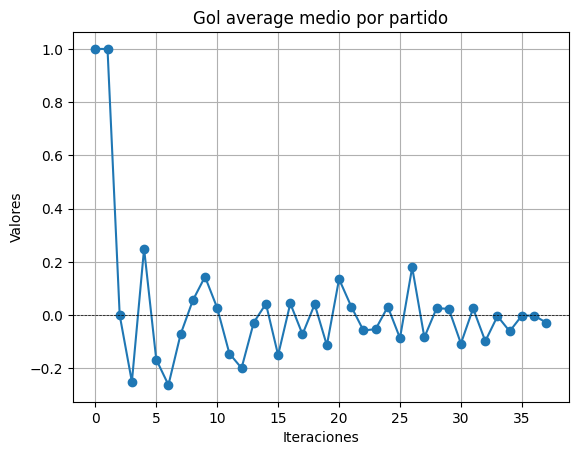

In [95]:
datos = get_diferencia_media_gol_average_por_partido(dataframe=dataframe_liga, equipo="Real Madrid")
iteraciones = range(len(datos))

plt.plot(iteraciones, datos, marker='o', linestyle='-')

plt.axhline(0, color='black', linewidth=0.5, linestyle='--')

plt.xlabel('Iteraciones')
plt.ylabel('Valores')

plt.title('Gol average medio por partido')

plt.grid(True)
plt.show()

### Graficar gol average medio y diferencias

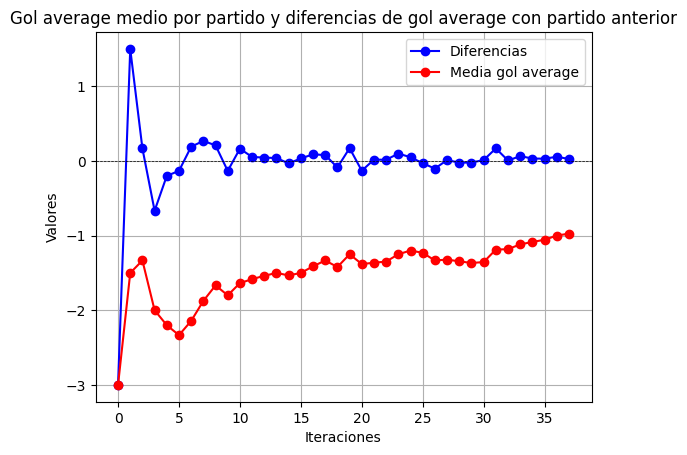

In [97]:
datos1 = get_diferencia_media_gol_average_por_partido(dataframe=dataframe_liga, equipo="Elche")
datos2 = get_media_gol_average_por_partido(dataframe=dataframe_liga,equipo="Elche")
iteraciones = range(len(datos1))

plt.plot(iteraciones, datos1, marker='o', linestyle='-', color='blue', label='Diferencias')
plt.plot(iteraciones, datos2, marker='o', linestyle='-', color='red', label='Media gol average')

plt.axhline(0, color='black', linewidth=0.5, linestyle='--')

plt.xlabel('Iteraciones')
plt.ylabel('Valores')

plt.title('Gol average medio por partido y diferencias de gol average con partido anterior')

plt.legend()
plt.grid(True)
plt.show()